In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import string
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import transformers
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from PIL import Image
import cv2

In [2]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-z37ul1qb
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-z37ul1qb
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 739.6 kB/s eta 0:00:000:00:01
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369547 sha256=39edf6d249ce5d94ef3f871c8434b33acb75a55b3514253fde643524a94d459e
  Stored in directory: /tmp/pip-ephem-wheel-cache-s_a0y3d5/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [3]:
sample_sub =pd.read_csv("/kaggle/input/datasets/ducknf/slovak-aoi-p1/sample_output.csv")
train_path = "/kaggle/input/datasets/ducknf/slovak-aoi-p1/train_data"

In [46]:
t = 0
n = 0
for filename in os.listdir(train_path):
    img = cv2.imread(os.path.join(train_path, filename),cv2.IMREAD_GRAYSCALE)
    b = np.all((img == 0) | (img == 255))
    t += b
    n += 1
p = 100*t/n
print(round(p, 2))

100.0


In [6]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)
encoder = torch.load('/kaggle/input/datasets/ducknf/slovak-aoi-p1/custom_archive/mnist_cvae8_encoder.pth', weights_only=False, map_location=device)
decoder = torch.load('/kaggle/input/datasets/ducknf/slovak-aoi-p1/custom_archive/mnist_cvae8_decoder.pth', weights_only=False, map_location=device)
encoder.eval()
decoder.eval()
def binarize(x):
    return (x > 0.5).float()
def autoencoder(x, latent_dim=8):
    return decoder(encoder(x)[:,:latent_dim])
directory = "obrazky"

cuda:0


In [7]:
imgs = sorted(os.listdir(train_path))
labs = []
letter_idxs=[]
for filename in imgs:
    img = Image.open(os.path.join(train_path, filename))
    img = np.array(img)
    img = torch.tensor(img, dtype=torch.float32).to(device)
    img = img / 255.0
    img = img.unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        reconstruct = autoencoder(img)
    err = torch.mean((img - reconstruct) ** 2).item()
    if err >= 0.1:
        labs.append(1)
        letter_idxs.append(filename)
    else:
        labs.append(0)

In [30]:
import clip
from PIL import Image
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
prompts = [f"A picture of the letter {c}" for c in letters]
text = clip.tokenize(prompts).to(device)
with torch.no_grad():
    text_features = model.encode_text(text)
    text_features /= text_features.norm(dim=-1, keepdim=True)
predicted_letters = {}
for filename in letter_idxs:
    img = Image.open(os.path.join(train_path, filename)).convert("RGB")
    image = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        similarity = image_features @ text_features.T
        pred_idx = similarity.argmax(dim=-1).item()
    img_id = int(os.path.splitext(filename)[0])
    predicted_letters[img_id] = letters[pred_idx]

KeyError: slice(None, 10, None)

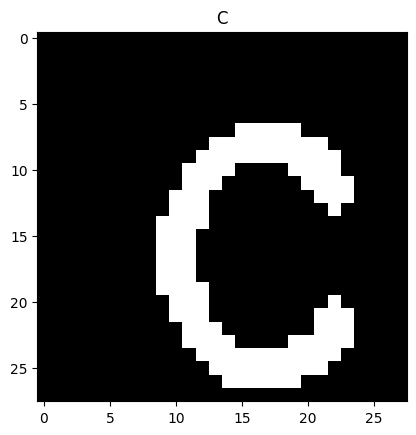

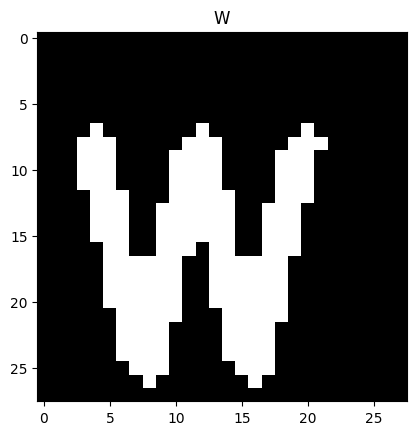

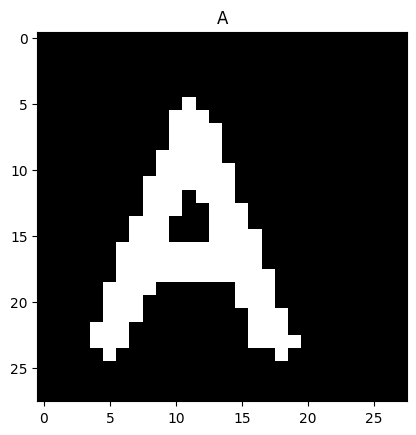

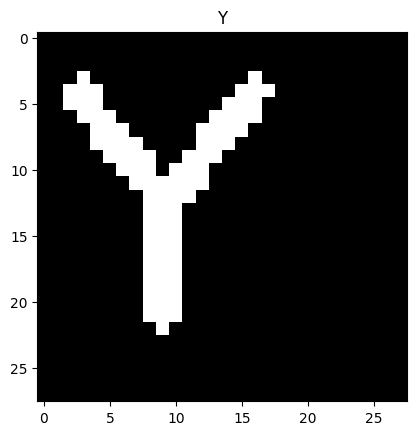

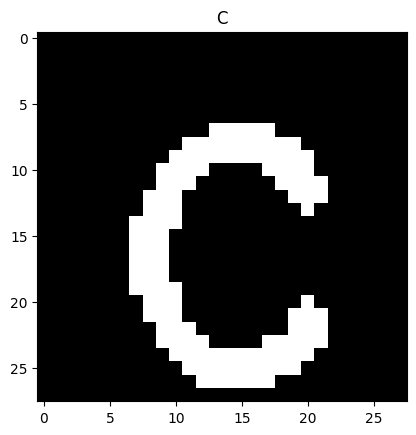

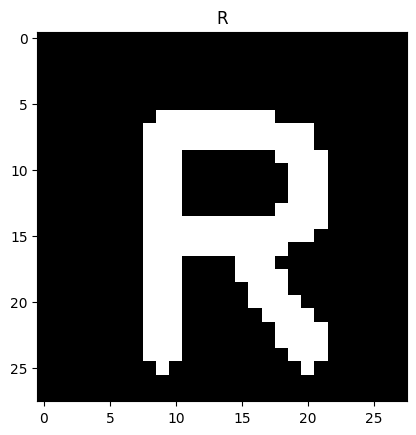

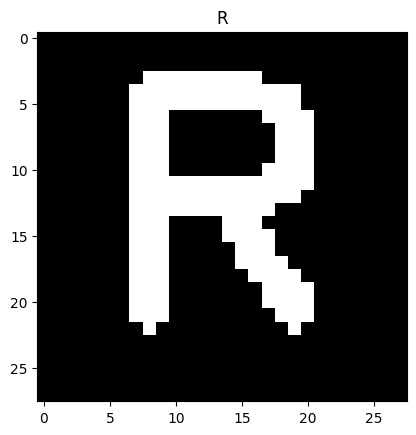

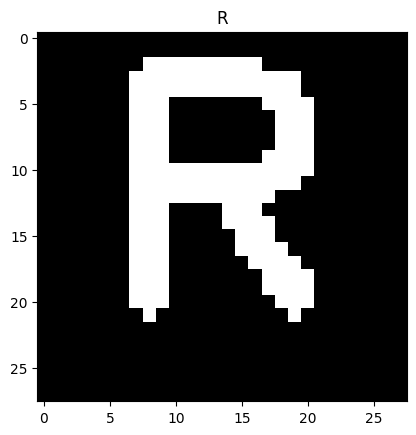

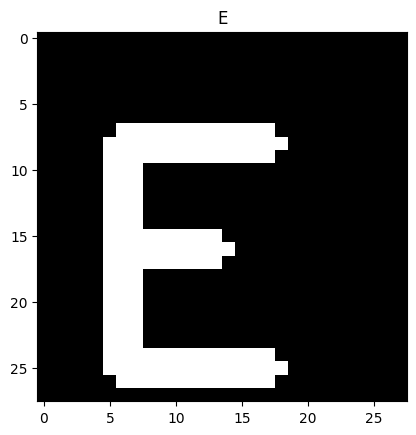

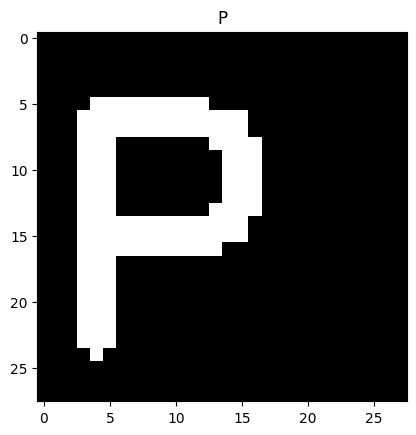

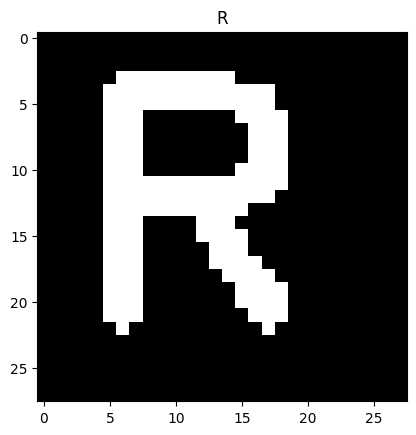

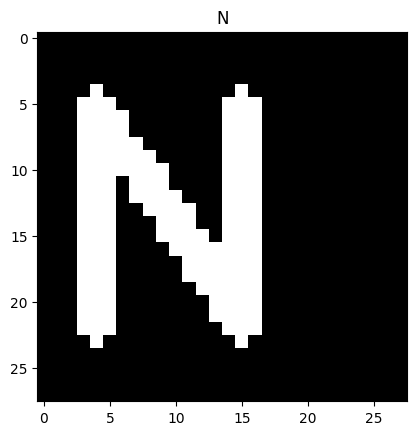

In [9]:
for i, filename in enumerate(letter_idxs):
    img = Image.open(os.path.join(train_path, filename)).convert("RGB")
    plt.imshow(img)
    plt.title(predicted_letters[i])
    plt.show()
    if i>10:
        break

In [10]:
cnt = 0;
for l in labs
    if(l==1):cnt+=1;

In [42]:
mask5 = sample_sub["subtaskID"] == 5
sample_sub.loc[mask5, "answer"] = " "
sample_sub.loc[mask5, "answer"] = (sample_sub.loc[mask5, "datapointID"].astype(int).map(predicted_letters).fillna(" "))
sample_sub.loc[sample_sub["subtaskID"]==3, "answer"]= labs
sample_sub.loc[sample_sub["subtaskID"]==2, "answer"]=0.21746
sample_sub.loc[sample_sub["subtaskID"] == 1, "answer"] = 100.0
sample_sub.loc[sample_sub["subtaskID"]==4, "answer"]= cnt

In [45]:
sample_sub.to_csv("sub.csv",index = False)